In [1]:
from datasets import load_dataset

import numpy as np
import torch
import matplotlib.pyplot as plt
from configurations.plot_config import set_font_sizes, apply_general_styles, create_fig, FONTSIZES
from configurations.data_config import make_params_dict , load_data, save_fig

from attention_nn.dataset import get_all_sentences, build_tokenizer, get_dataloader
from attention_nn.model import create_model

apply_general_styles()

/u/c/cerazova/miniconda3/envs/transf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Statistics

In [2]:
# Define configuration

config = {
    'dataset_size': 10000,
    'train_fraction': 0.9,
    'batch_size': 1,
    'L': 128,
    'datasource': 'roneneldan/TinyStories',
}

# Prepare data loaders and tokenizer
print('Preparing data loaders...')
train_dataloader, val_dataloader , tokenizer = get_dataloader(config)
vocab_size = tokenizer.get_vocab_size()
print(f'Vocabulary size = {vocab_size}. Maximum entropy per token = {np.log(vocab_size):.4f} nats.')
pad_id = tokenizer.token_to_id("[PAD]")

Preparing data loaders...
Min sequence length = 53
Max sequence length = 1040
Vocabulary size = 8043. Maximum entropy per token = 8.9926 nats.


In [8]:
# Measure token frequency in all dataset for each position in sequence
token_counts = np.zeros((config['L'], vocab_size))

for batch in train_dataloader:
    input = batch['input'][0].numpy() # (seq_len,)
    token_counts[np.arange(config['L']), input] += 1
for batch in val_dataloader:
    input = batch['input'][0].numpy() # (seq_len,)
    token_counts[np.arange(config['L']), input] += 1

# Eliminate data from padding tokens
token_counts[:, pad_id] = 0
total_counts = token_counts.sum(axis=0)  # (vocab_size,)
sorted_tokens = np.argsort(-total_counts)  # Indices of tokens sorted by frequency descending
token_counts = token_counts[:, sorted_tokens]  # Sort token counts accordingly
total_counts = total_counts[sorted_tokens]

# Compute entropy per position
token_frequencies = token_counts / token_counts.sum(axis=1, keepdims=True)  # (L, vocab_size)
entropies = -np.nansum(token_frequencies * np.log(token_frequencies + 1e-12), axis=1)  # (L,)

# Compute total entropy
total_token_frequencies = total_counts / total_counts.sum()
total_entropy = -np.nansum(total_token_frequencies * np.log(total_token_frequencies + 1e-12))


Figure saved on /u/c/cerazova/Transformers/plots/2026-01 as token_frequencies_L128_dataset_size10000.png


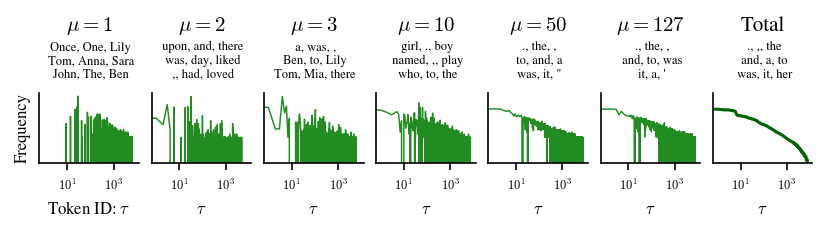

Figure saved on /u/c/cerazova/Transformers/plots/2026-01 as entropy_per_seq_position_L128_dataset_size10000.png


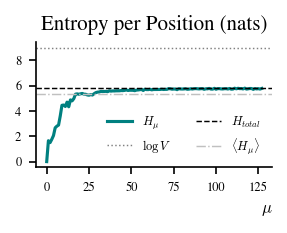

In [82]:
# Setup and variables for plotting
L = config['L']
window = 1

k = 9
# pos_to_plot = np.linspace(1,L-1-window,m).astype(int)
pos_to_plot = [1,2,3,10,50,L-1]
m = len(pos_to_plot)

h_ratios = [0.5,1.0]
set_font_sizes(conf='tight')
fig , axes = create_fig(ncols=m+1,nrows=2,size='double',h=0.2,w=0.75,sharey=True, h_ratios=h_ratios)

for i in range(m+1):
    if i < m:
        # print(pos_to_plot[i],pos_to_plot[i]+window)
        # freqs = token_counts[pos_to_plot[i]:pos_to_plot[i]+window].sum(axis=0)
        freqs = token_counts[pos_to_plot[i]]
    else:
        freqs = total_counts
    freqs /= freqs.sum()
    # Top k tokens ids
    top_k_tokes_id = np.argsort(-freqs)[:k]
    top_k_tokens = [tokenizer.id_to_token(sorted_tokens[j]) for j in top_k_tokes_id]
    # print(f'idx={i}',top_k_tokens)
    ax = axes[0,i]
    ax.set_axis_off()
    
        
    # if i == 0: ax.set_ylabel('Frequent\nTokens',size=FONTSIZES['s'])
    text = '\n'.join([f' {top_k_tokens[j]}, {top_k_tokens[j+1]}, {top_k_tokens[j+2]}' for j in range(0,k-2,3)]) 
    ax.text(0.5, 0.5, text, fontsize=FONTSIZES['xs'], va='center', ha='center', transform=ax.transAxes)
    ax.set_title(rf'$\mu={pos_to_plot[i]}$' if i < m else 'Total')


    # Plot token frequency distribution
    ax = axes[1,i]
    if i == 0: ax.set_ylabel('Frequency',size=FONTSIZES['s'])
    
    ax.plot(freqs,color='forestgreen' if i < m else 'darkgreen',lw=0.7 if i < m else 1.5)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'Token ID: $\tau$' if i == 0 else r'$\tau$',size=FONTSIZES['s'])
    ax.set_xticks([10,1000],[r'$10^1$',r'$10^3$'])

    ax.set_yticks([])
    
# fig.text(0.025, 0.75, 'Frequent\nTokens', fontsize=FONTSIZES['s'], va='center', ha='center', transform=fig.transFigure,rotation=90)

names = ['dataset_size','L']
params = {k: config[k] for k in names}
save_fig(fig,'token_frequencies',params=params,date=True)
plt.show()


fig , axes = create_fig(ncols=1,nrows=1,size='double',h=0.2,w=0.25)
ax = axes

ax.plot(entropies, color='teal', lw=1.5,label=r'$H_\mu$')
ax.set_xlabel(r'$\mu$',size=FONTSIZES['s'],loc='right')
# ax.set_ylabel(r'$H_\mu$',size=FONTSIZES['s'])
ax.axhline(np.log(vocab_size), color='gray', ls=':', lw=0.7, label=r'$\log V$')
ax.axhline(total_entropy, color='k', ls='--', lw=.7, label=r'$H_{total}$')
ax.axhline(entropies.mean(), color='silver', ls='-.', lw=.7, label=r'$\langle H_\mu \rangle$')
ax.legend(fontsize=FONTSIZES['xs'],frameon=False,ncols=2)
ax.set_title('Entropy per Position (nats)')
save_fig(fig,'entropy_per_seq_position',params=params,date=True)
plt.show()


# Model at Initialization

In [10]:
# Define configuration

config = {
    'd': 1000,
    'dataset_size': 10000,
    'train_fraction': 0.9,
    'batch_size': 64,
    'L': 124,
    'dropout': 0.0,
    'rank': None,
    'num_epochs': 5,
    'lr': 0.001,
    'datasource': 'roneneldan/TinyStories',
    'fr_emb': False,
    'fr_att': False,
    'type_enc': 'learned',
    'skip_residual': False,
    'sigma': 1,
    'beta': 0.5
}



In [11]:
# Prepare data loaders and tokenizer
print('Preparing data loaders...')
train_dataloader, val_dataloader , tokenizer = get_dataloader(config)
config['vocab_size'] = tokenizer.get_vocab_size()
print(f'Vocabulary size = {config["vocab_size"]}. Maximum entropy per token = {np.log(config["vocab_size"]):.4f} nats.')
pad_id = tokenizer.token_to_id("[PAD]")

# Set device and build model
model , device = create_model(config)
print(f'Model built on device: {device}')

Preparing data loaders...
Min sequence length = 53
Max sequence length = 1040
Vocabulary size = 8043. Maximum entropy per token = 8.9926 nats.
Model built on device: cuda


In [9]:

CE_loss = torch.nn.CrossEntropyLoss(ignore_index=pad_id,label_smoothing=0.0)
for batch in train_dataloader:
    input = batch['input'].to(device) # (batch_size, seq_len)
    label = batch['label'].to(device) # (batch_size, seq_len)
    mask = batch['attention_mask'].to(device) # (batch_size, seq_len, seq_len)

    e = model.input_embeddings(input)  # (batch, seq_len, d_model)
    x = model.positional_encoding(e)  # (batch, seq_len, d_model)
    
    # divide each row by sqrt(len_of_the_row)
    dot = model.attention_layer.dot(x) #/np.sqrt(config['d']) # (batch, seq_len, seq_len)
    A =  torch.softmax(dot.masked_fill(mask==0,-1e9), dim=-1)
    y = A @ x
    z = model.residual_connection(x, y)
    # layer normalization of z
    z_mean = z.mean(dim=-1, keepdim=True)
    z_std = z.std(dim=-1, keepdim=True) + 1e-6
    # z = (z - z_mean) / z_std
    logits = model.projection(z)
    # logits = z @ model.input_embeddings.embedding.weight.t()#/np.sqrt(config['d'])    # (batch, seq_len, vocab_size)
    # logits = model(input,mask)
    prediction = torch.softmax(logits, dim=-1)

    loss = CE_loss(logits.view(-1,config['vocab_size']) , label.view(-1))
    break

E = model.input_embeddings.embedding.weight.t()
W = model.attention_layer.W.weight
projection_weight = model.projection.weight

print(f'Input dimension = {config["d"]}, vocabulary size = {config["vocab_size"]} , sequence length = {config["L"]}.')
print(f'{input.shape = }')
print(f'{e.shape = }')
print(f'{x.shape = }')
print(f'{dot.shape = }')
print(f'{A.shape = }')
print(f'{y.shape = }')
print(f'{z.shape = }')
print(f'{logits.shape = }')
print(f'{E.shape = }')
print(f'{W.shape = }')
print(f'{projection_weight.shape = }')
print(f'{loss.item() = }')


Input dimension = 1000, vocabulary size = 10000 , sequence length = 124.
input.shape = torch.Size([57, 124])
e.shape = torch.Size([57, 124, 1000])
x.shape = torch.Size([57, 124, 1000])
dot.shape = torch.Size([57, 124, 124])
A.shape = torch.Size([57, 124, 124])
y.shape = torch.Size([57, 124, 1000])
z.shape = torch.Size([57, 124, 1000])
logits.shape = torch.Size([57, 124, 10000])
E.shape = torch.Size([1000, 10000])
W.shape = torch.Size([1000, 1000])
projection_weight.shape = torch.Size([10000, 1000])
loss.item() = 9.830046653747559


0.99849766


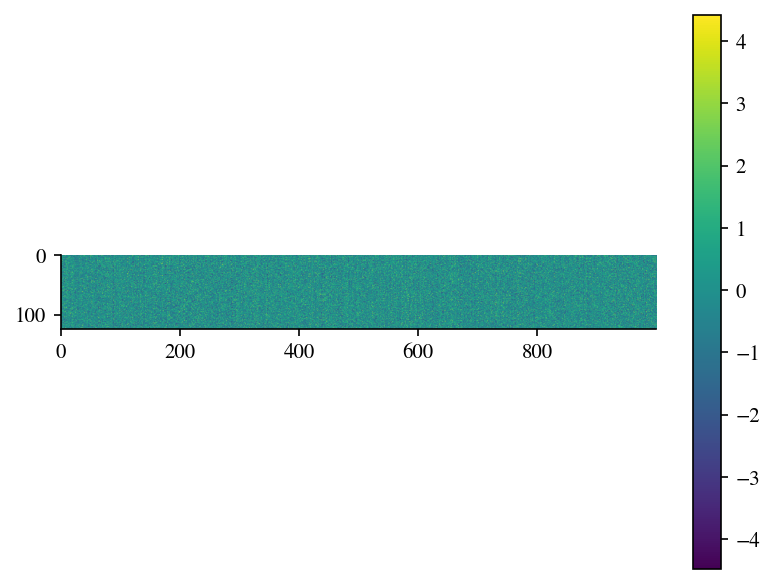

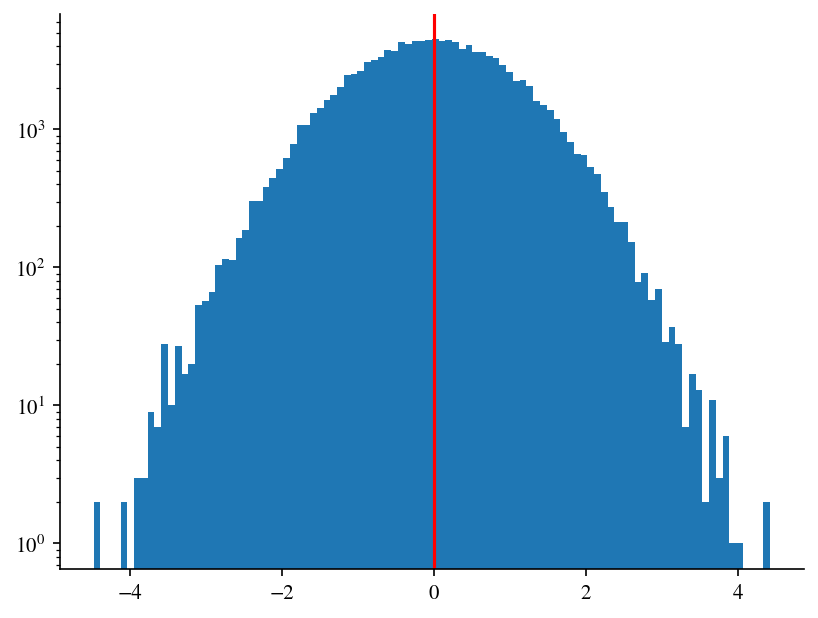

(0.0, 1120.2029796191407)

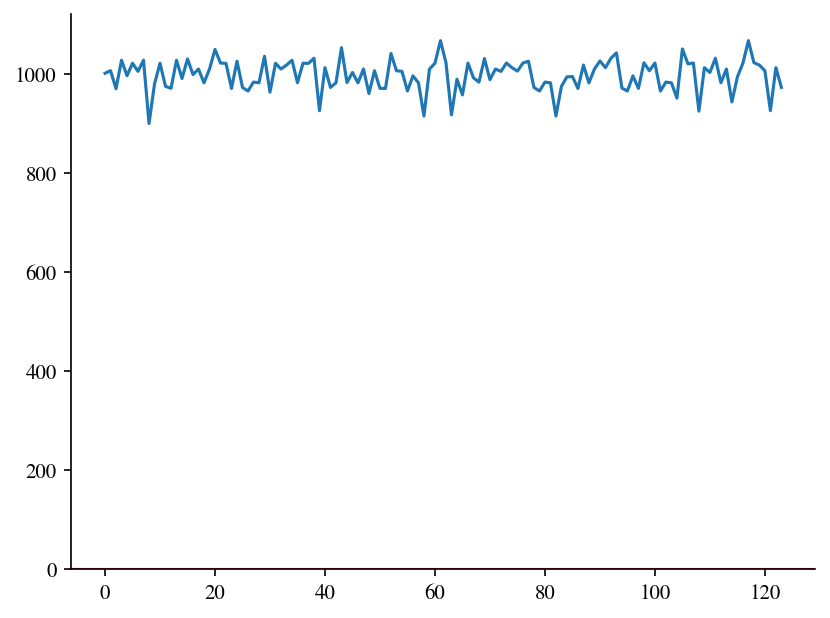

In [11]:
i_batch = 1

var_to_plot = (e)[i_batch].detach().cpu().numpy()  # (seq_len, d_model)

print(var_to_plot.std()   )
plt.imshow(var_to_plot)#,vmax=0.05)
plt.colorbar()

plt.show()
plt.hist(var_to_plot.flatten(), bins=100)
plt.yscale('log')
plt.axvline(x=1/config['vocab_size'], color='red')

plt.show()

plt.plot((var_to_plot**2).sum(axis=1))
plt.axhline(y=1/config['vocab_size'], color='red')
plt.ylim(bottom=0)

In [80]:
np.sqrt(1024)

np.float64(32.0)

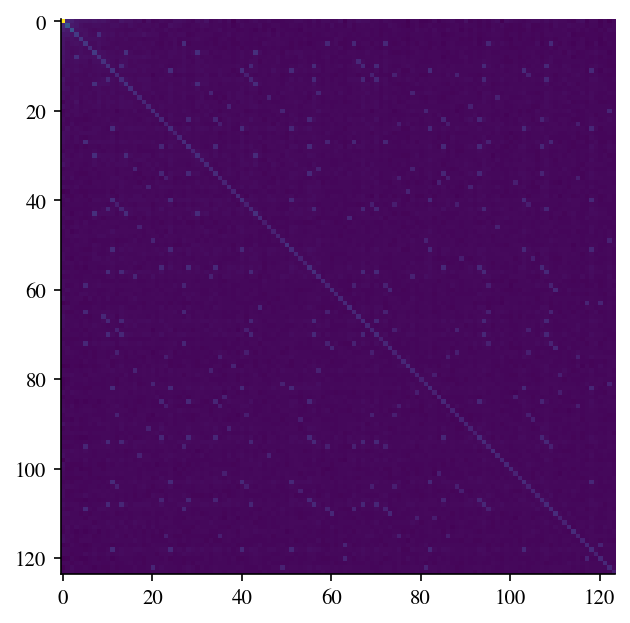

In [63]:
C = var_to_plot @ var_to_plot.T / var_to_plot.shape[1]
eigenvalues, eigenvectors = np.linalg.eigh(C)
# plt.scatter(eigenvalues,eigenvalues)
# plt.plot(np.sort(eigenvalues)[::-1])
plt.imshow(C)

In [64]:
i_batch = 10
beta = 1.0
prob = (beta*h[i_batch]).softmax(dim=-1).detach().cpu().numpy()  # (seq_len, vocab_size)
sequence = input[i_batch].detach().cpu().numpy()  # (seq_len,)

mu = 0
p = prob[mu]
tok = np.argmax(p)
print(f"Token with highest probability for position {mu+1}: {tok}  = '{tokenizer.id_to_token(tok)}' with probability {p[tok]:.6f}")
print(f"Token at position {mu}: {sequence[mu]} = '{tokenizer.id_to_token(sequence[mu])}'")
print(f"Actual token at position {mu+1}: {sequence[mu+1]}  = '{tokenizer.id_to_token(sequence[mu+1])}'")
print(f"probability of actual next token: {p[sequence[mu+1]]:.6f}")
print(f"Uniform probability: {1/config['vocab_size']:.6f}")
print(f'Participation ratio at position : {np.sum(p**2):.6f}')
plt.plot(prob[mu])
plt.axhline(1/config['vocab_size'], color='red', linestyle='--', label='Uniform probability')
plt.ylim(bottom=0)
# print(prob[mu])

NameError: name 'h' is not defined

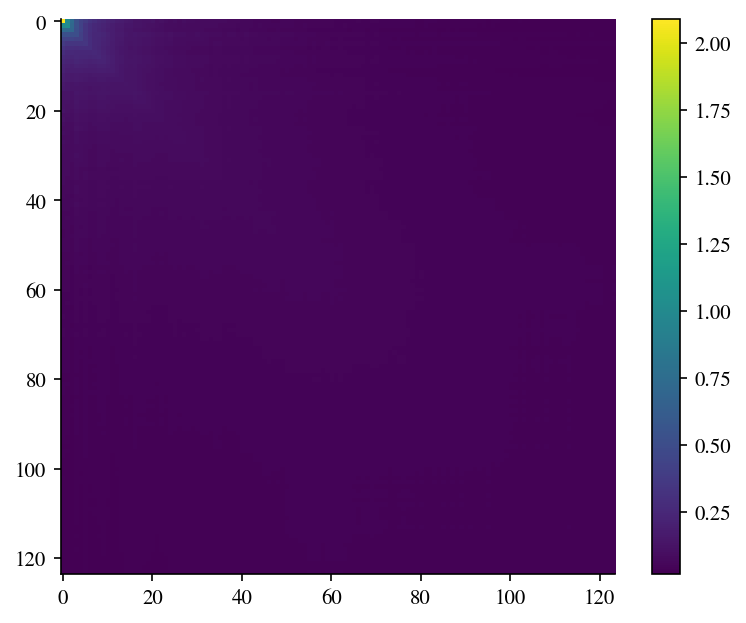

In [66]:
p = (y)[0].detach().cpu().numpy()
c = p @ p.T / config['d']
# c.shape
plt.imshow(c)
plt.colorbar()
# plt.imshow(p[i_batch].detach().cpu().numpy())

tensor(0.0001)
0.0001


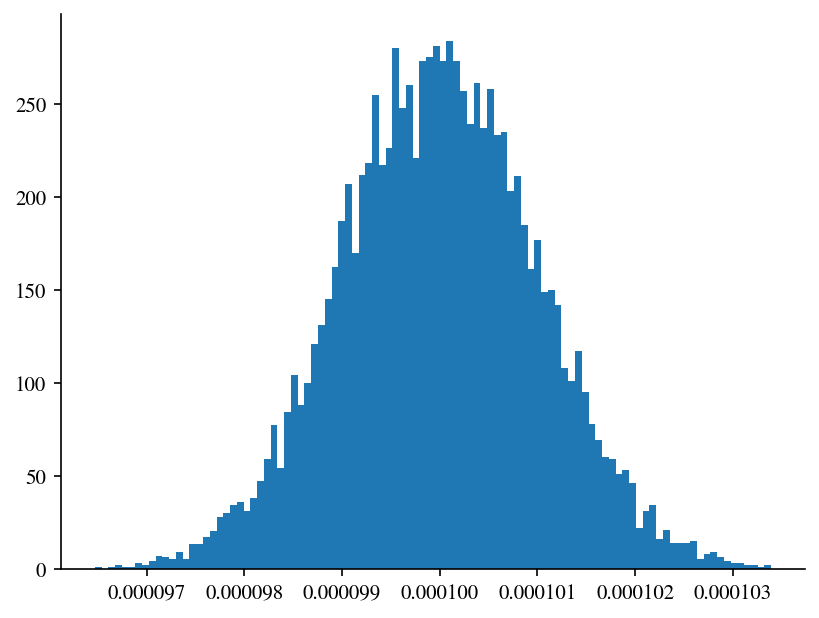

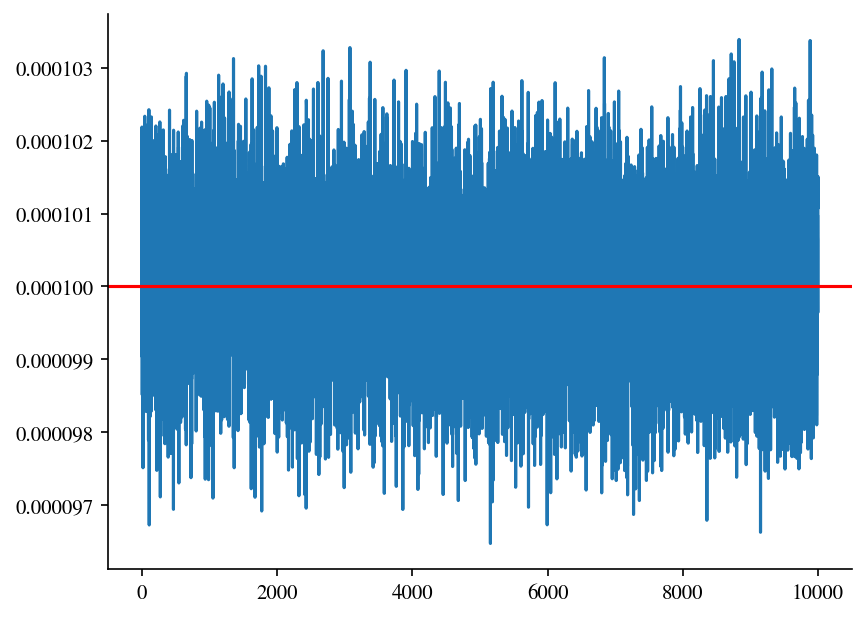

In [100]:
n = 10000
x = torch.randn(n)/np.sqrt(n)
e = torch.exp(x)
s = e.sum()
a = e / s

plt.hist(a.numpy(), bins=100)
print((a**2).sum())
print(1/n)
# plt.hist(a.numpy(), bins=100)
plt.show()
plt.plot(a.numpy())
plt.axhline(1/n, color='red')